In [27]:
import pandas as pd
import os
import json
from utils.eda_utils import EDAUtils, FeatureEngineering, DataCleaningUtils
from utils.ml_utils_v2 import RegressionAnalysis, FeaturePredictiveEvaluator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib
import time

In [28]:
eda_utils = EDAUtils()
dcu = DataCleaningUtils()
fe = FeatureEngineering()

In [29]:
# Enable automatic reloading of modules before executing user code (useful during development)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "country_panel_data")
RAW_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "raw_data")
PARQUET_PATH = os.path.join(PROCESSED_DATA_DIR_PATH, "panel_2002_2022_136countries_68vars.parquet")
JSON_METADATA_PATH =os.path.join(PROCESSED_DATA_DIR_PATH, "panel_2002_2022_136countries_68vars_metadata.json")
OUTPUT_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "output")
MODELS_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "models")
TRAINING_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "training")

In [31]:
# Load dataframe
df = pd.read_parquet(PARQUET_PATH)
df.head()

,iso_alpha_3,year,country_name,cap_gdp_current_usd,cap_gdp_per_capita_constant_2015,cap_gdp_per_capita_ppp_current,cap_population,cap_electoral_democracy_idx,cap_liberal_democracy_idx,cap_corruption_idx,...,inc_cumulative_climate_laws,inc_has_framework_law,inc_n_climate_laws,inc_n_policies_total,inc_n_sectors_covered,inc_has_carbon_pricing,inc_has_renewable_target,inc_has_efficiency_standard,inc_has_ev_policy,inc_has_coal_phaseout
0,AFG,2002,Afghanistan,3.825701e+09,338.139974,926.507941,21378117.0,0.220,0.084,0.919,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AFG,2003,Afghanistan,4.520947e+09,346.071627,966.962032,22733049.0,0.227,0.086,0.919,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AFG,2004,Afghanistan,5.224897e+09,338.637274,971.633503,23560654.0,0.238,0.091,0.931,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AFG,2005,Afghanistan,6.203257e+09,363.640141,1076.087353,24404567.0,0.319,0.113,0.942,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AFG,2006,Afghanistan,6.971758e+09,367.758312,1121.834471,25424094.0,0.373,0.199,0.955,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 71 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   iso_alpha_3                                2856 non-null   object 
 1   year                                       2856 non-null   int64  
 2   country_name                               2856 non-null   object 
 3   cap_gdp_current_usd                        2856 non-null   float64
 4   cap_gdp_per_capita_constant_2015           2856 non-null   float64
 5   cap_gdp_per_capita_ppp_current             2856 non-null   float64
 6   cap_population                             2856 non-null   float64
 7   cap_electoral_democracy_idx                2856 non-null   float64
 8   cap_liberal_democracy_idx                  2856 non-null   float64
 9   cap_corruption_idx                         2856 non-null   float64
 10  cap_rule_of_law_idx     

In [33]:
# Load metadata
with open(JSON_METADATA_PATH, "r") as file:
    df_metadata = json.load(file) 
df_metadata.keys()

dict_keys(['configuration', 'dimensions', 'zero_filled_variables'])

In [34]:
# Obtain emission fields
emission_fields = df_metadata["dimensions"]["EMISSIONS"]
emission_fields

['con_co2_incl_luc_mt',
 'con_co2_intensity',
 'con_co2_mt',
 'con_co2_per_capita',
 'con_edgar_ghg_mt',
 'con_edgar_ghg_gg',
 'con_ghg_per_capita',
 'con_methane_mt',
 'con_nitrous_oxide_mt',
 'con_share_global_co2_pct',
 'con_total_emissions',
 'con_total_ghg_mt']

In [35]:
df[emission_fields]

,con_co2_incl_luc_mt,con_co2_intensity,con_co2_mt,con_co2_per_capita,con_edgar_ghg_mt,con_edgar_ghg_gg,con_ghg_per_capita,con_methane_mt,con_nitrous_oxide_mt,con_share_global_co2_pct,con_total_emissions,con_total_ghg_mt
0,6.391,169.01,1.341,0.063,17.044710,17044.710352,0.937,10.375,3.299,0.005,0.12,20.037
1,6.169,241.76,1.560,0.069,17.732318,17732.317739,0.914,10.687,3.434,0.006,0.22,20.769
2,3.636,227.85,1.237,0.053,17.789451,17789.451447,0.804,10.651,3.412,0.004,0.18,18.934
3,2.983,219.51,1.890,0.077,18.191324,18191.324358,0.787,10.901,3.561,0.006,0.18,19.199
4,3.244,255.56,2.159,0.085,18.461036,18461.036258,0.764,11.122,3.418,0.007,0.23,19.426
...,...,...,...,...,...,...,...,...,...,...,...,...
2851,10.131,395.55,11.209,0.746,31.273375,31273.374543,1.813,11.831,5.206,0.031,3.73,27.250
2852,16.597,429.25,10.267,0.672,30.207339,30207.339246,2.008,11.636,5.099,0.028,3.64,30.672
2853,7.897,371.09,8.491,0.547,28.341567,28341.566541,1.555,11.314,4.591,0.024,2.49,24.146
2854,12.444,269.55,10.223,0.647,29.525357,29525.356700,1.767,11.840,4.858,0.028,2.31,27.907


In [36]:
# define target variable
target_var = "con_edgar_ghg_mt"

## Data prep

### Filter data to avoid leakage

In [37]:
emission_fields.remove(target_var)
emission_fields

['con_co2_incl_luc_mt',
 'con_co2_intensity',
 'con_co2_mt',
 'con_co2_per_capita',
 'con_edgar_ghg_gg',
 'con_ghg_per_capita',
 'con_methane_mt',
 'con_nitrous_oxide_mt',
 'con_share_global_co2_pct',
 'con_total_emissions',
 'con_total_ghg_mt']

In [38]:
df_filtered = df.drop(columns=emission_fields + ["country_name"])
df_filtered.columns

Index(['iso_alpha_3', 'year', 'cap_gdp_current_usd',
       'cap_gdp_per_capita_constant_2015', 'cap_gdp_per_capita_ppp_current',
       'cap_population', 'cap_electoral_democracy_idx',
       'cap_liberal_democracy_idx', 'cap_corruption_idx',
       'cap_rule_of_law_idx', 'cap_accountability_idx',
       'cap_civil_liberties_idx', 'cap_control_corruption',
       'cap_govt_effectiveness', 'cap_political_stability',
       'cap_regulatory_quality', 'cap_rule_of_law', 'cap_voice_accountability',
       'con_agricultural_land_pct', 'con_bioenergy', 'con_coal', 'con_demand',
       'con_demand_per_capita', 'con_electricity_access_pct',
       'con_electricity_generation_twh', 'con_energy_per_capita_kwh',
       'con_forest_area_pct', 'con_fossil_share_elec_pct', 'con_gas',
       'con_gas_and_other_fossil', 'con_hydro',
       'con_hydro,_bioenergy_and_other_renewables', 'con_net_elec_imports_twh',
       'con_nuclear', 'con_other_fossil', 'con_population',
       'con_primary_energy_twh'

### Filter some redoundant variables

In [39]:
redoundant_fields = [
    "cap_gdp_per_capita_constant_2015",
    "cap_gdp_current_usd",
    "con_population",
    "cap_population",
    "cap_electoral_democracy_idx",
    "cap_accountability_idx",
    "con_electricity_generation_twh",
    "con_total_generation",
    "con_gas_and_other_fossil",
    "con_hydro,_bioenergy_and_other_renewables",
    "con_ndgain_readiness",
    "inc_n_policies_total",
    "inc_n_sectors_covered",
]

In [40]:
df_filtered = df_filtered.drop(columns=redoundant_fields)

### Add Policy Stringency Index data

In [41]:
#TODO
policy_index_df = pd.read_csv(os.path.join(RAW_DATA_DIR_PATH, "policy_index", "oecd_policy_stringency_index.csv"))
policy_index_df.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,...,TIME_PERIOD,Time period,OBS_VALUE,Observation value,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,DECIMALS,Decimals
0,DATAFLOW,OECD.ENV.EPI:DSD_CAPMF@DF_CAPMF(1.0),Climate actions and policies measurement frame...,I,CAN,Canada,A,Annual,POL_STRINGENCY,Policy stringency,...,1990,NaN,0.0,NaN,A,Normal value,0,Units,2,Two
1,DATAFLOW,OECD.ENV.EPI:DSD_CAPMF@DF_CAPMF(1.0),Climate actions and policies measurement frame...,I,CAN,Canada,A,Annual,POL_STRINGENCY,Policy stringency,...,1990,NaN,0.0,NaN,A,Normal value,0,Units,2,Two
2,DATAFLOW,OECD.ENV.EPI:DSD_CAPMF@DF_CAPMF(1.0),Climate actions and policies measurement frame...,I,CAN,Canada,A,Annual,POL_STRINGENCY,Policy stringency,...,1990,NaN,0.0,NaN,A,Normal value,0,Units,2,Two
3,DATAFLOW,OECD.ENV.EPI:DSD_CAPMF@DF_CAPMF(1.0),Climate actions and policies measurement frame...,I,CAN,Canada,A,Annual,POL_STRINGENCY,Policy stringency,...,1990,NaN,0.0,NaN,A,Normal value,0,Units,2,Two
4,DATAFLOW,OECD.ENV.EPI:DSD_CAPMF@DF_CAPMF(1.0),Climate actions and policies measurement frame...,I,CAN,Canada,A,Annual,POL_STRINGENCY,Policy stringency,...,1990,NaN,0.0,NaN,A,Normal value,0,Units,2,Two


In [42]:
print("Observation type value counts: ", policy_index_df["Frequency of observation"].value_counts())
print("="*50)
print("Amount of unique countries: ", policy_index_df["REF_AREA"].nunique())
print("="*50)
print("Observation status value counts: ", policy_index_df["Observation status"].value_counts())

Observation type value counts:  Frequency of observation
Annual    392496
Name: count, dtype: int64
Amount of unique countries:  52
Observation status value counts:  Observation status
Normal value                         316847
Estimated value                       40698
Missing value; data cannot exist      19626
Missing value; suppressed             15096
Data included in another category       189
Not significant                          40
Name: count, dtype: int64


In [43]:
# keep only the normal and estimated values
policy_index_df = policy_index_df[policy_index_df["Observation status"].isin(["Normal value", "Estimated value"])]
print("Observation status value counts after filtering: ", policy_index_df["Observation status"].value_counts())

Observation status value counts after filtering:  Observation status
Normal value       316847
Estimated value     40698
Name: count, dtype: int64


In [44]:
# keep only the REF_AREA, TIME_PERIOD, Climate actions and policies and OBS_VALUE columns
policy_index_df = policy_index_df[["REF_AREA", "TIME_PERIOD", "Climate actions and policies", "OBS_VALUE"]]
# rename columns
policy_index_df = policy_index_df.rename(columns={"REF_AREA": "iso_alpha_3", "TIME_PERIOD": "year", "Climate actions and policies": "climate_actions_and_policies", "OBS_VALUE": "policy_stringency_index"})
policy_index_df.head()

,iso_alpha_3,year,climate_actions_and_policies,policy_stringency_index
0,CAN,1990,Carbon Tax - Buildings,0.0
1,CAN,1990,Independent climate advisory body - number of ...,0.0
2,CAN,1990,Air Emission Standards - Nox,0.0
3,CAN,1990,Mandatory energy labels for appliances,0.0
4,CAN,1990,Building energy codes,0.0


In [45]:
# Aggregate the policy index by taking the mean for each country-year combination
policy_index_agg = policy_index_df.groupby(["iso_alpha_3", "year"])["policy_stringency_index"].mean().reset_index()
policy_index_agg.head()

,iso_alpha_3,year,policy_stringency_index
0,ARG,1990,0.10291
1,ARG,1991,0.10291
2,ARG,1992,0.10218
3,ARG,1993,0.10218
4,ARG,1994,0.26677


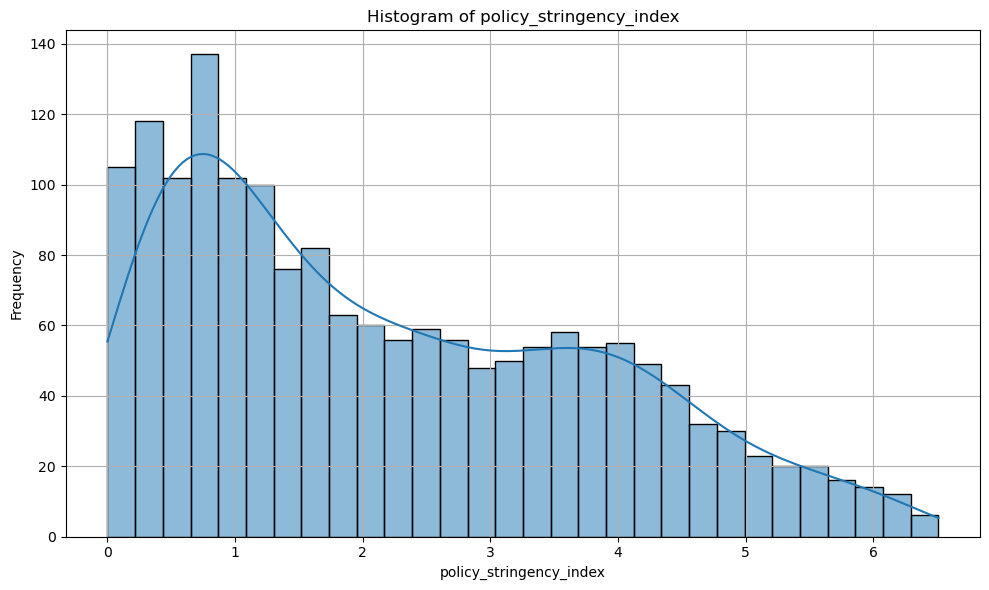

In [46]:
eda_utils.plot_simple_histogram(policy_index_agg, "policy_stringency_index")

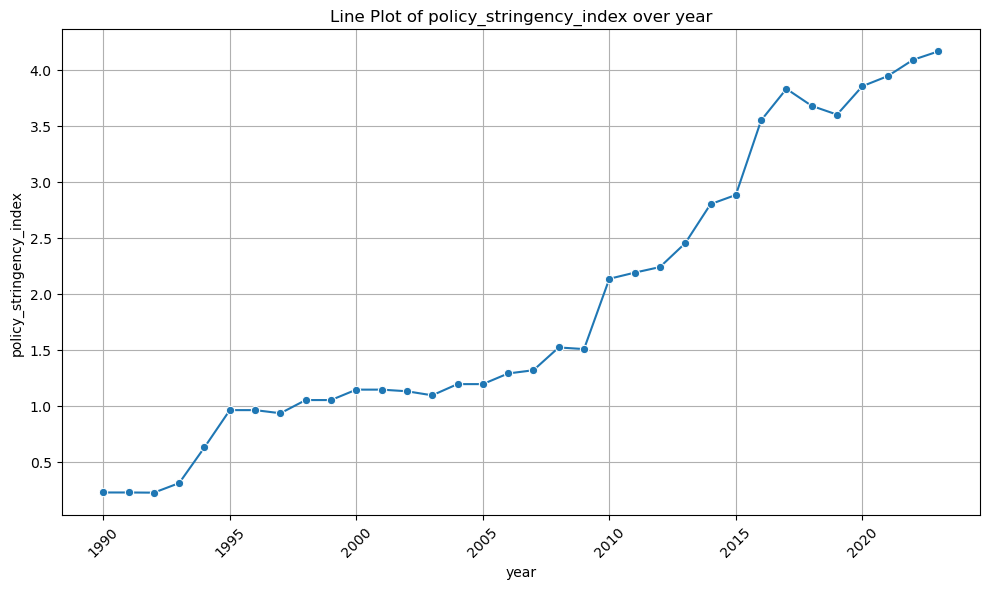

In [47]:
eda_utils.plot_simple_lineplot(policy_index_agg[policy_index_agg.iso_alpha_3 == "MEX"], "year", "policy_stringency_index")


In [48]:
df_filtered.head()

,iso_alpha_3,year,cap_gdp_per_capita_ppp_current,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_civil_liberties_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,...,inc_has_ets,inc_carbon_pricing_coverage,inc_cumulative_climate_laws,inc_has_framework_law,inc_n_climate_laws,inc_has_carbon_pricing,inc_has_renewable_target,inc_has_efficiency_standard,inc_has_ev_policy,inc_has_coal_phaseout
0,AFG,2002,926.507941,0.084,0.919,0.137,0.523,-1.251137,-1.587687,-2.035034,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AFG,2003,966.962032,0.086,0.919,0.129,0.550,-1.344180,-1.175768,-2.198372,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AFG,2004,971.633503,0.091,0.931,0.123,0.546,-1.350647,-0.945146,-2.295682,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AFG,2005,1076.087353,0.113,0.942,0.117,0.542,-1.447252,-1.228816,-2.067510,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AFG,2006,1121.834471,0.199,0.955,0.116,0.540,-1.446292,-1.473652,-2.219135,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [49]:
# Check for duplicates before the merge
duplicates = policy_index_agg.duplicated(subset=["iso_alpha_3", "year"]).sum()
print(f"Duplicate country-year rows in policy data: {duplicates}")

Duplicate country-year rows in policy data: 0


In [50]:
# Merge the aggregated policy index with the socio-economic data
#TODO: Filter the df_filtered to keep only the countries present in policy data, then impute the missing year index values with 0 (assuming that no policy means a stringency index of 0)
isos_in_policy_data = policy_index_agg["iso_alpha_3"].unique()
df_filtered = df_filtered[df_filtered["iso_alpha_3"].isin(isos_in_policy_data)].copy()
df_filtered = df_filtered.merge(policy_index_agg, left_on=["iso_alpha_3", "year"], right_on=["iso_alpha_3", "year"], how="left")
df_filtered = df_filtered.sort_values(["iso_alpha_3", "year"])
df_filtered["policy_stringency_index"] = (
    df_filtered
    .groupby("iso_alpha_3")["policy_stringency_index"]
    .ffill()
    .fillna(0)
)

# df_filtered = df_filtered.fillna(0)
df_filtered[df_filtered.iso_alpha_3 == "ARG"].head()

,iso_alpha_3,year,cap_gdp_per_capita_ppp_current,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_civil_liberties_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,...,inc_carbon_pricing_coverage,inc_cumulative_climate_laws,inc_has_framework_law,inc_n_climate_laws,inc_has_carbon_pricing,inc_has_renewable_target,inc_has_efficiency_standard,inc_has_ev_policy,inc_has_coal_phaseout,policy_stringency_index
0,ARG,2002,9953.464929,0.666,0.518,0.627,0.924,-0.417056,-0.228479,-0.776545,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.596262
1,ARG,2003,10933.392549,0.645,0.555,0.543,0.917,-0.479977,-0.034220,-0.359838,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.592233
2,ARG,2004,12117.679742,0.641,0.555,0.549,0.917,-0.414410,0.015197,-0.610935,...,0.0,6.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.592233
3,ARG,2005,13464.812847,0.632,0.555,0.549,0.917,-0.377738,-0.097979,-0.041775,...,0.0,8.0,1.0,2.0,0.0,1.0,1.0,0.0,0.0,0.628269
4,ARG,2006,14843.577866,0.621,0.555,0.549,0.914,-0.331239,-0.033916,0.001968,...,0.0,10.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.730993


In [52]:
#TODO: Test an interaction term with gov_efficiency or something like that.
df_filtered["policy_index_x_gov_eff"] = df_filtered["policy_stringency_index"] * df_filtered["cap_govt_effectiveness"]
df_filtered["policy_index_x_corruption"] = df_filtered["policy_stringency_index"] * df_filtered["cap_control_corruption"]
df_filtered["policy_index_x_regulatory_quality"] = df_filtered["policy_stringency_index"] * df_filtered["cap_regulatory_quality"]

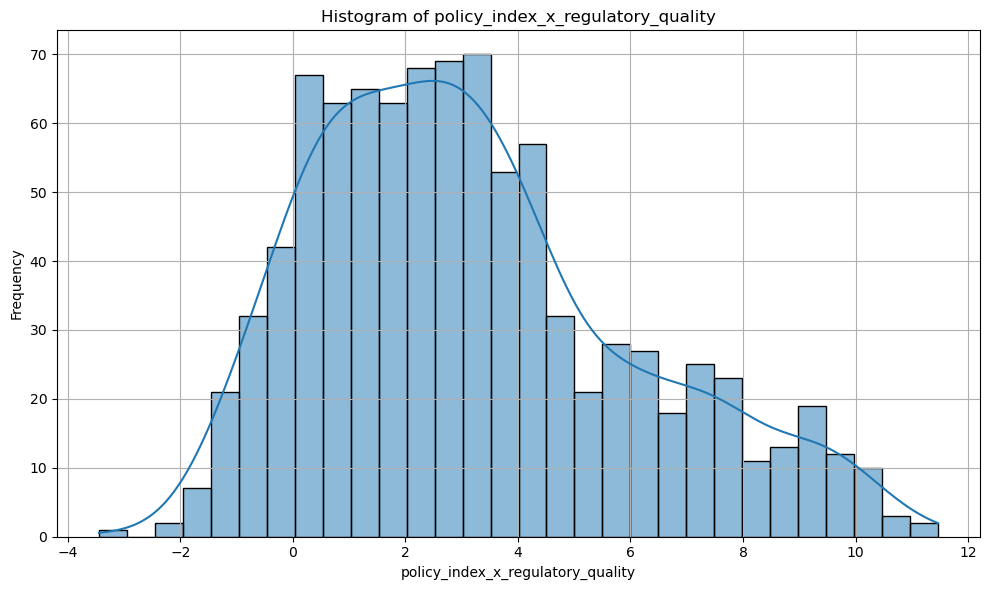

In [53]:
eda_utils.plot_simple_histogram(df_filtered, "policy_index_x_regulatory_quality")

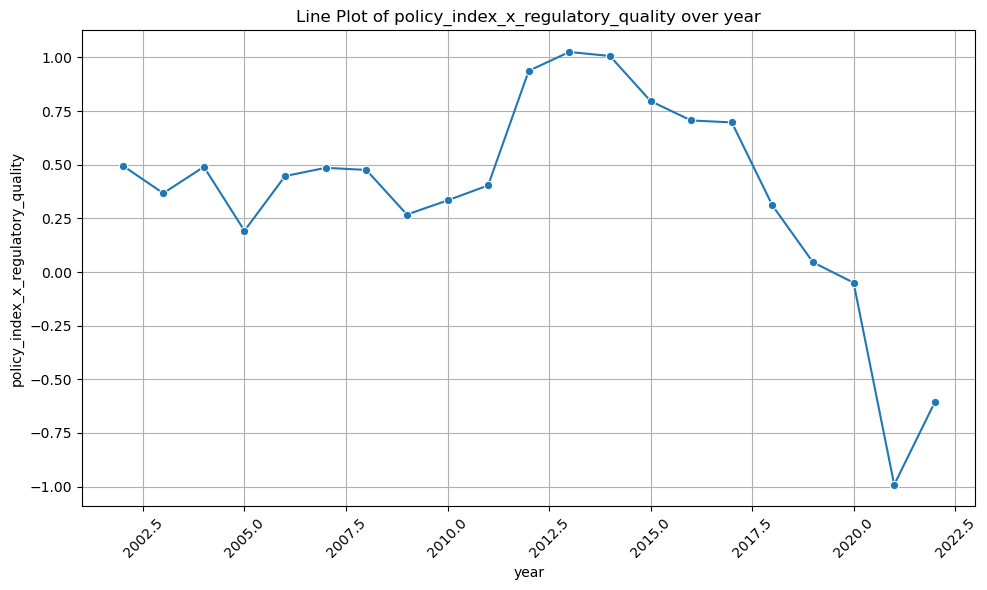

In [54]:
eda_utils.plot_simple_lineplot(df_filtered[df_filtered.iso_alpha_3 == "MEX"], "year", "policy_index_x_regulatory_quality")

### Fix Skewness

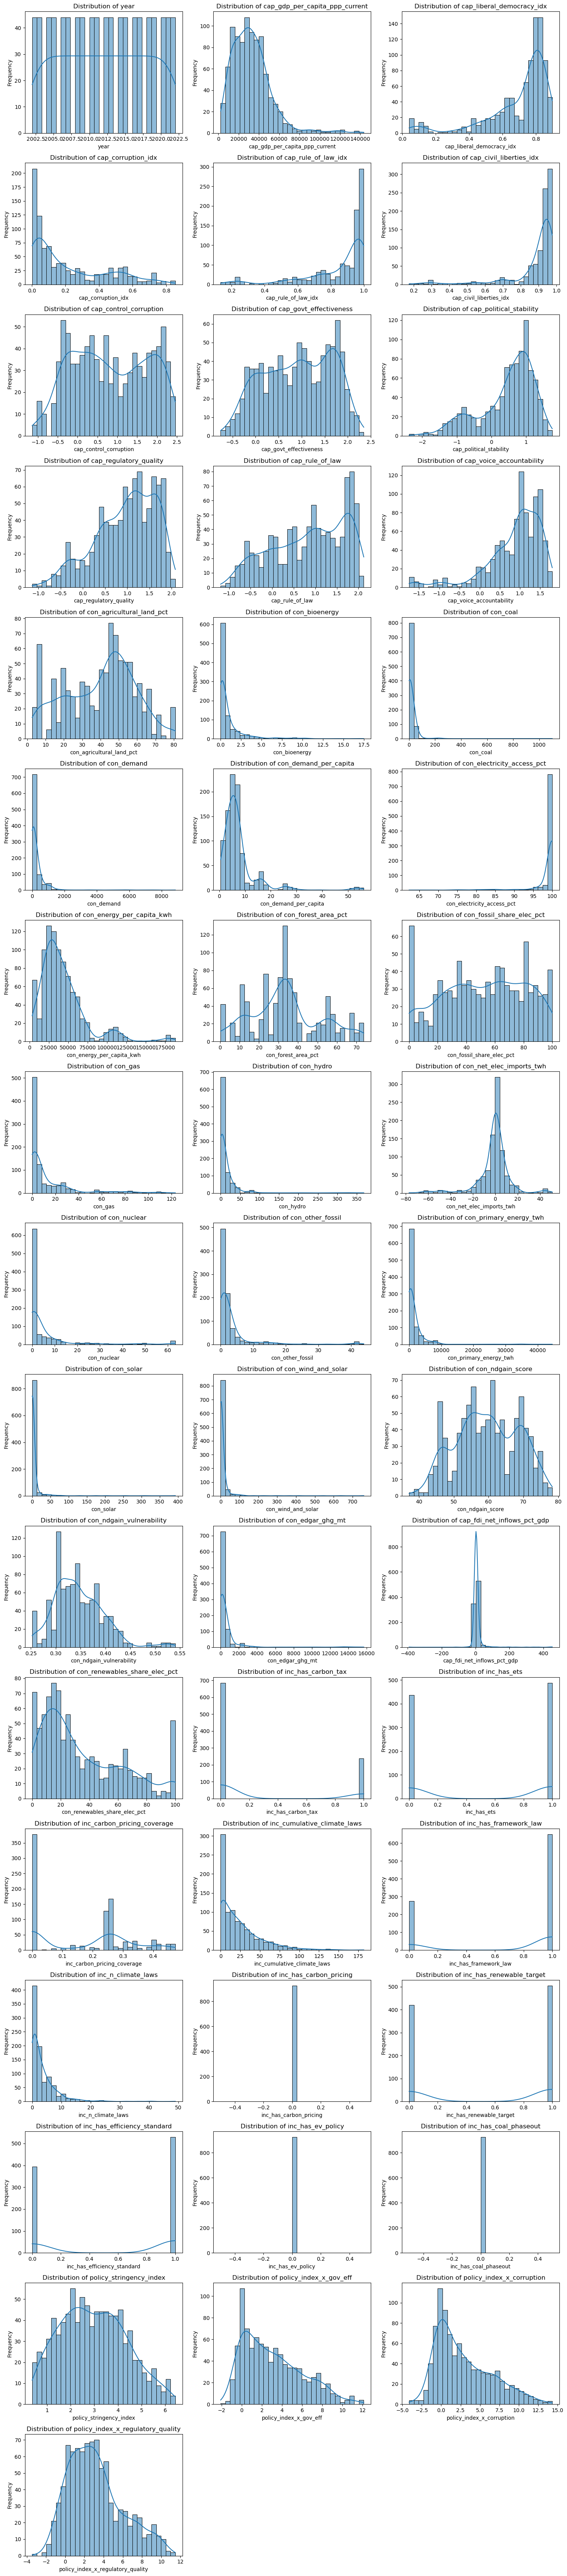

In [55]:
eda_utils.plot_numeric_fields_distributions(df_filtered)

In [56]:
df_filtered.describe()

,year,cap_gdp_per_capita_ppp_current,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_civil_liberties_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,cap_regulatory_quality,...,inc_n_climate_laws,inc_has_carbon_pricing,inc_has_renewable_target,inc_has_efficiency_standard,inc_has_ev_policy,inc_has_coal_phaseout,policy_stringency_index,policy_index_x_gov_eff,policy_index_x_corruption,policy_index_x_regulatory_quality
count,924.00000,924.000000,924.000000,924.000000,924.000000,924.000000,924.000000,924.000000,924.000000,924.000000,...,924.000000,924.0,924.000000,924.000000,924.0,924.0,924.000000,924.000000,924.000000,924.000000
mean,2012.00000,32553.791088,0.698610,0.215043,0.844219,0.883045,0.815773,0.911242,0.452211,0.954874,...,3.463203,0.0,0.545455,0.572511,0.0,0.0,2.959824,3.078798,2.891053,3.169559
std,6.05858,19463.080748,0.191521,0.222828,0.201042,0.144280,0.943999,0.730798,0.785751,0.670163,...,4.869894,0.0,0.498199,0.494982,0.0,0.0,1.387807,2.922462,3.598049,2.852320
min,2002.00000,2277.069748,0.041000,0.002000,0.134000,0.175000,-1.141307,-0.757419,-2.376027,-1.141973,...,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.375648,-2.101136,-4.138655,-3.446165
25%,2007.00000,19101.240773,0.632000,0.031750,0.765000,0.886000,0.024837,0.306560,0.056894,0.493246,...,0.000000,0.0,0.000000,0.000000,0.0,0.0,1.886987,0.546706,0.056732,0.981452
50%,2012.00000,29921.715988,0.776000,0.111000,0.945000,0.937000,0.743746,0.960083,0.667455,1.072017,...,2.000000,0.0,1.000000,1.000000,0.0,0.0,2.883016,2.452217,1.952111,2.776436
75%,2017.00000,41470.589659,0.823000,0.388000,0.978250,0.956000,1.673834,1.572748,1.014735,1.522730,...,5.000000,0.0,1.000000,1.000000,0.0,0.0,3.966073,5.086156,5.252736,4.666288
max,2022.00000,143381.897534,0.897000,0.854000,0.999000,0.976000,2.459118,2.347191,1.753184,2.081799,...,49.000000,0.0,1.000000,1.000000,0.0,0.0,6.424994,12.122319,14.323832,11.466092


In [57]:
# Identify full o zeros and drop them
zero_cols = df_filtered.columns[(df_filtered == 0).all()]
df_filtered = df_filtered.drop(columns=zero_cols)
print(zero_cols)


Index(['inc_has_carbon_pricing', 'inc_has_ev_policy', 'inc_has_coal_phaseout'], dtype='object')


In [58]:
# Identify binary columns
binary_cols = [
    c for c in df_filtered.columns
    if df_filtered[c].nunique(dropna=True) == 2
]
binary_cols

['inc_has_carbon_tax',
 'inc_has_ets',
 'inc_has_framework_law',
 'inc_has_renewable_target',
 'inc_has_efficiency_standard']

In [59]:
# Identify columns with low variance and with a lot of zeros

def get_zeros_and_variance_check_df(df):
    zeros_and_variance_check = []
    for field in df.select_dtypes(np.number):
        zero_share = (df[field] == 0).mean()
        field_var = df[field].var()

        if field in binary_cols:
            binary_flag = True
        else:
            binary_flag = False


        zeros_and_variance_check.append((field, zero_share, field_var, binary_flag))

    zeros_and_variance_check_df = pd.DataFrame(data=zeros_and_variance_check, columns=["field_name", "field_zero_share", "field_variance", "bianry_flag"])
    return zeros_and_variance_check_df

In [60]:
zeros_and_variance_check_df = get_zeros_and_variance_check_df(df_filtered)

In [61]:
# zeros_and_variance_check_df.to_clipboard(index=False)

In [62]:
skew = df_filtered[[col for col in df_filtered.columns if col not in binary_cols]].select_dtypes("number").skew().sort_values(ascending=False)
skew.head(20)

con_solar                         11.332885
con_wind_and_solar                11.074230
con_coal                           7.105613
con_demand                         6.645677
cap_fdi_net_inflows_pct_gdp        6.275212
con_hydro                          6.166514
con_edgar_ghg_mt                   5.982252
con_primary_energy_twh             5.800578
con_other_fossil                   4.061880
con_bioenergy                      3.989582
con_demand_per_capita              3.894650
inc_n_climate_laws                 3.565496
con_nuclear                        3.299983
con_gas                            2.584684
con_energy_per_capita_kwh          2.036905
inc_cumulative_climate_laws        1.728847
cap_gdp_per_capita_ppp_current     1.689753
cap_corruption_idx                 0.986371
con_ndgain_vulnerability           0.857640
con_renewables_share_elec_pct      0.831074
dtype: float64

In [63]:
skew.tail(10)

con_agricultural_land_pct    -0.214258
cap_rule_of_law              -0.398989
cap_regulatory_quality       -0.637391
cap_political_stability      -1.001865
con_net_elec_imports_twh     -1.221663
cap_voice_accountability     -1.644959
cap_rule_of_law_idx          -1.809643
cap_liberal_democracy_idx    -1.841277
cap_civil_liberties_idx      -2.875410
con_electricity_access_pct   -4.463547
dtype: float64

In [64]:
highly_skewed_fields = skew[skew.abs() >= 1].index.to_list()
highly_skewed_fields

['con_solar',
 'con_wind_and_solar',
 'con_coal',
 'con_demand',
 'cap_fdi_net_inflows_pct_gdp',
 'con_hydro',
 'con_edgar_ghg_mt',
 'con_primary_energy_twh',
 'con_other_fossil',
 'con_bioenergy',
 'con_demand_per_capita',
 'inc_n_climate_laws',
 'con_nuclear',
 'con_gas',
 'con_energy_per_capita_kwh',
 'inc_cumulative_climate_laws',
 'cap_gdp_per_capita_ppp_current',
 'cap_political_stability',
 'con_net_elec_imports_twh',
 'cap_voice_accountability',
 'cap_rule_of_law_idx',
 'cap_liberal_democracy_idx',
 'cap_civil_liberties_idx',
 'con_electricity_access_pct']

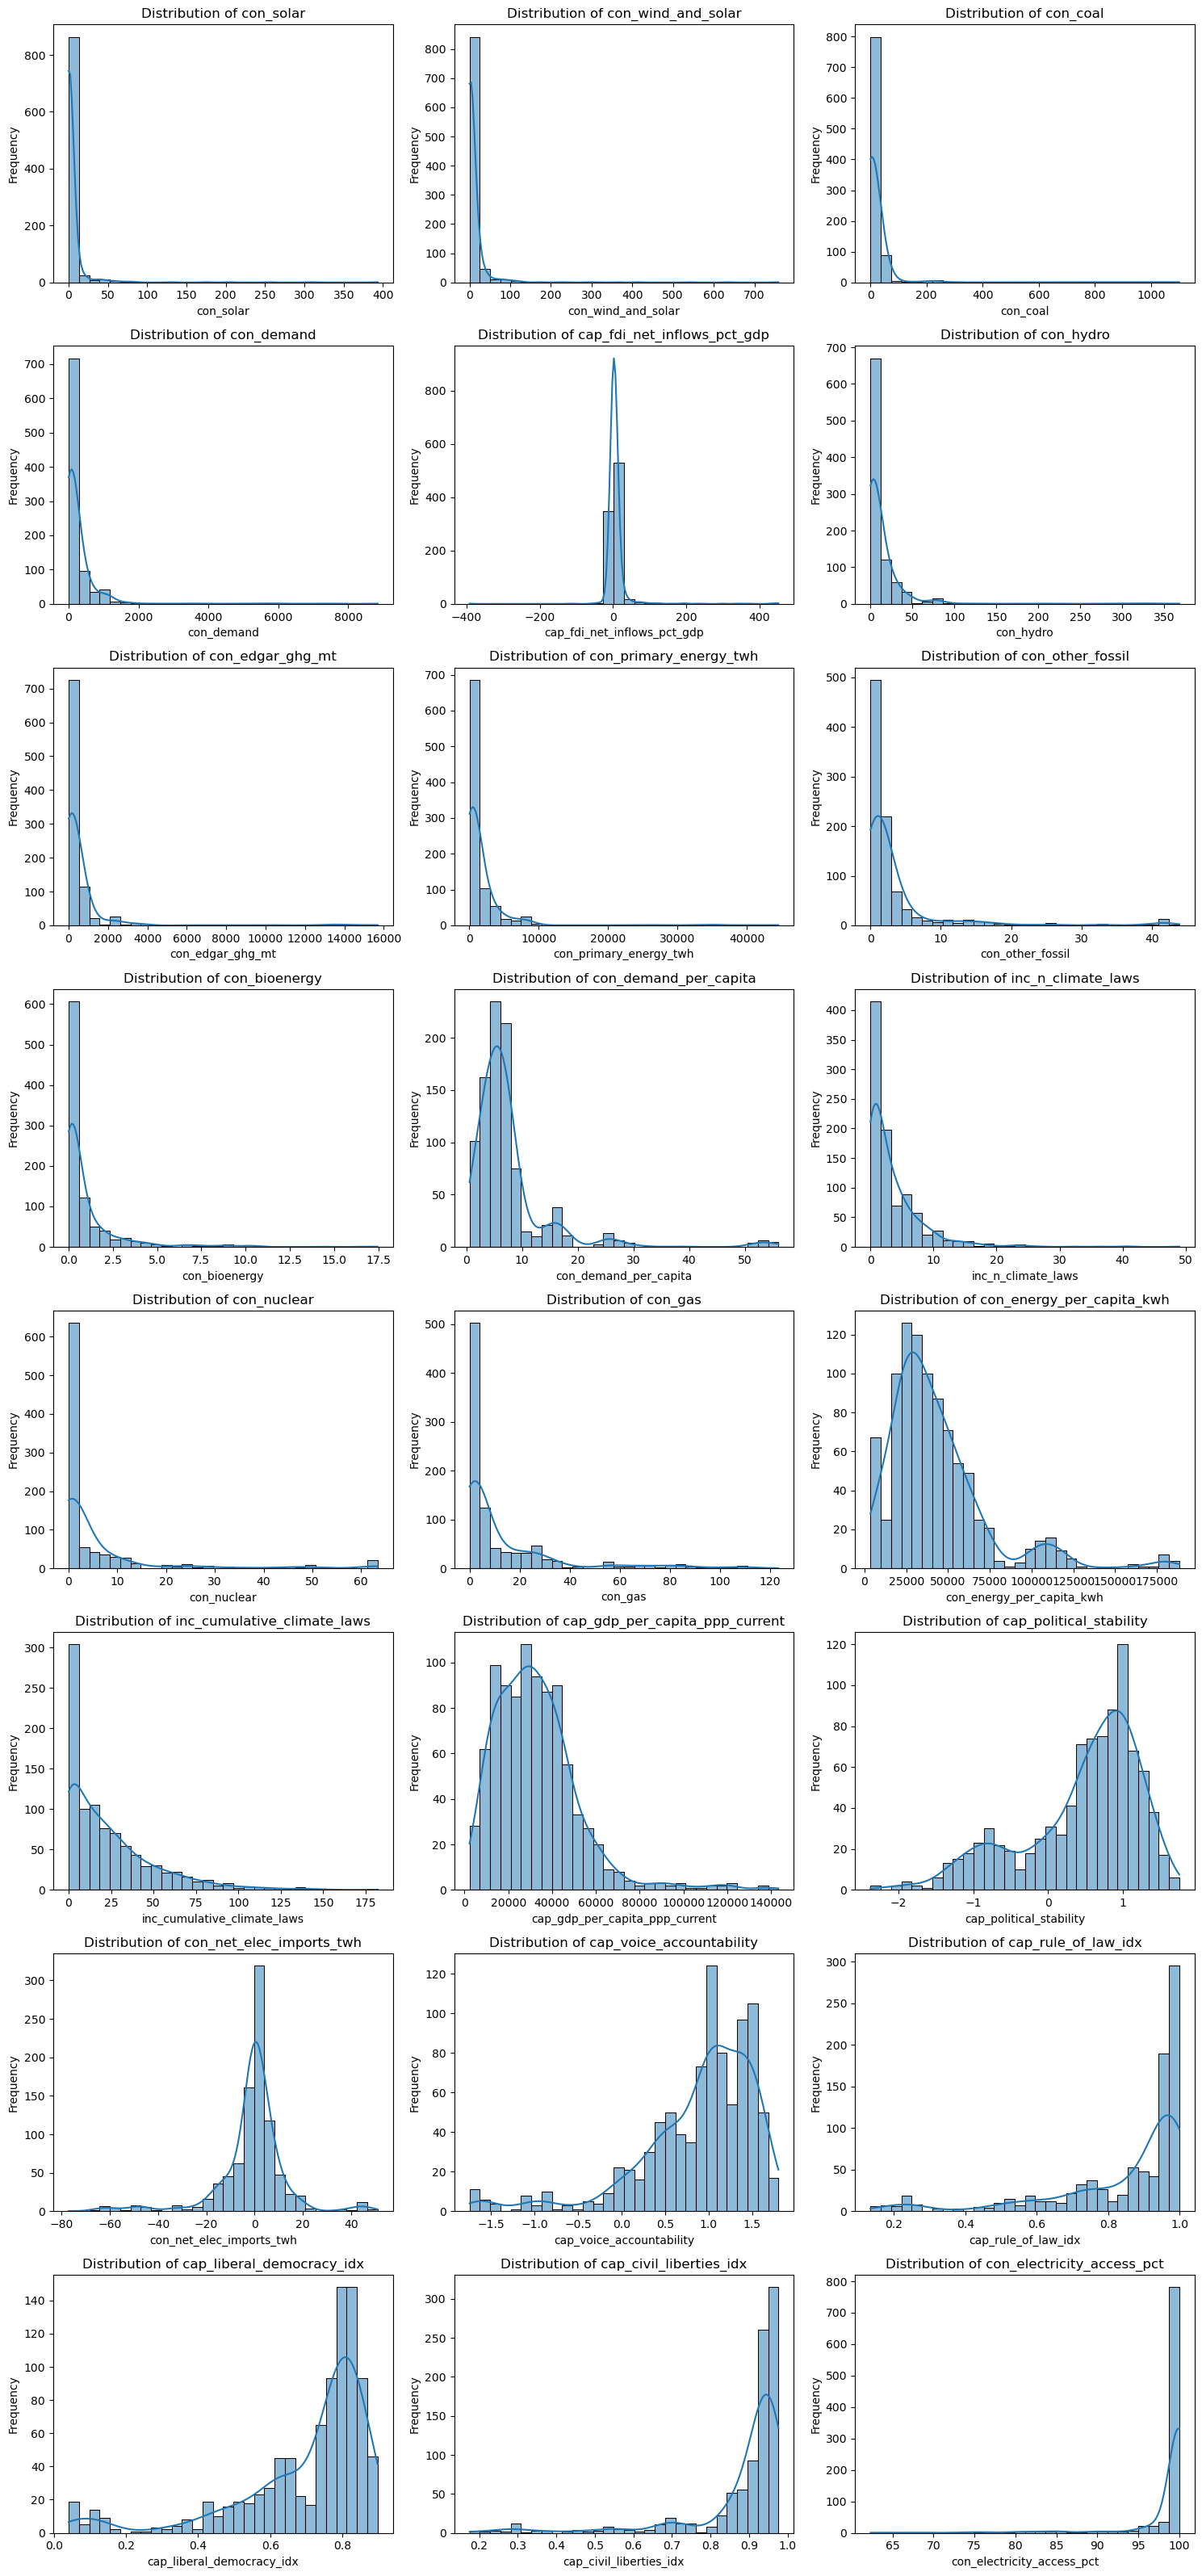

In [65]:
eda_utils.plot_numeric_fields_distributions(df_filtered[highly_skewed_fields])

### Second pass to fix skewness using log transformation

In [66]:
# Log transform highly skewed fields
for field in highly_skewed_fields:
    df_filtered[f"x_log_signed_{field}"] = np.sign(df_filtered[field]) * np.log1p(np.abs(df_filtered[field]))
df_filtered.head()

,iso_alpha_3,year,cap_gdp_per_capita_ppp_current,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_civil_liberties_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,...,x_log_signed_con_energy_per_capita_kwh,x_log_signed_inc_cumulative_climate_laws,x_log_signed_cap_gdp_per_capita_ppp_current,x_log_signed_cap_political_stability,x_log_signed_con_net_elec_imports_twh,x_log_signed_cap_voice_accountability,x_log_signed_cap_rule_of_law_idx,x_log_signed_cap_liberal_democracy_idx,x_log_signed_cap_civil_liberties_idx,x_log_signed_con_electricity_access_pct
0,ARG,2002,9953.464929,0.666,0.518,0.627,0.924,-0.417056,-0.228479,-0.776545,...,9.758889,0.000000,9.205776,-0.574671,1.934416,0.231162,0.486738,0.510426,0.654406,4.575741
1,ARG,2003,10933.392549,0.645,0.555,0.543,0.917,-0.479977,-0.034220,-0.359838,...,9.816974,0.000000,9.299668,-0.307366,1.796747,0.299456,0.433729,0.497740,0.650761,4.577799
2,ARG,2004,12117.679742,0.641,0.555,0.549,0.917,-0.414410,0.015197,-0.610935,...,9.870591,1.945910,9.402503,-0.476815,1.497388,0.308984,0.437610,0.495306,0.650761,4.579852
3,ARG,2005,13464.812847,0.632,0.555,0.549,0.917,-0.377738,-0.097979,-0.041775,...,9.918760,2.197225,9.507909,-0.040926,1.585145,0.238412,0.437610,0.489806,0.650761,4.581902
4,ARG,2006,14843.577866,0.621,0.555,0.549,0.914,-0.331239,-0.033916,0.001968,...,9.957114,2.397895,9.605390,0.001966,1.211941,0.338924,0.437610,0.483043,0.649195,4.584967


In [67]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 71 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   iso_alpha_3                                  924 non-null    object 
 1   year                                         924 non-null    int64  
 2   cap_gdp_per_capita_ppp_current               924 non-null    float64
 3   cap_liberal_democracy_idx                    924 non-null    float64
 4   cap_corruption_idx                           924 non-null    float64
 5   cap_rule_of_law_idx                          924 non-null    float64
 6   cap_civil_liberties_idx                      924 non-null    float64
 7   cap_control_corruption                       924 non-null    float64
 8   cap_govt_effectiveness                       924 non-null    float64
 9   cap_political_stability                      924 non-null    float64
 10  ca

In [68]:
# Drop the skewed fields since we have the log transform version
df_log_transformed = df_filtered.drop(columns=highly_skewed_fields)

In [69]:
skew_after_log_transform = df_log_transformed[[col for col in df_log_transformed.columns if col not in binary_cols]].select_dtypes("number").skew().sort_values(ascending=False)
skew_after_log_transform.head(20)

x_log_signed_con_solar                 2.222551
x_log_signed_con_bioenergy             1.673450
x_log_signed_con_wind_and_solar        1.358133
x_log_signed_con_other_fossil          1.264278
x_log_signed_con_nuclear               1.141439
x_log_signed_con_coal                  1.104203
cap_corruption_idx                     0.986371
con_ndgain_vulnerability               0.857640
con_renewables_share_elec_pct          0.831074
policy_index_x_corruption              0.814797
policy_index_x_gov_eff                 0.695212
policy_index_x_regulatory_quality      0.654390
x_log_signed_con_hydro                 0.609640
x_log_signed_con_demand_per_capita     0.599329
x_log_signed_con_gas                   0.545075
x_log_signed_inc_n_climate_laws        0.346320
con_forest_area_pct                    0.294499
x_log_signed_con_primary_energy_twh    0.291690
x_log_signed_con_demand                0.275314
x_log_signed_con_edgar_ghg_mt          0.242812
dtype: float64

In [70]:
zeros_and_variance_check_df_after_transformation = get_zeros_and_variance_check_df(df_log_transformed)
zeros_and_variance_check_df_after_transformation.head()

,field_name,field_zero_share,field_variance,bianry_flag
0,year,0.0,36.706392,False
1,cap_corruption_idx,0.0,0.049652,False
2,cap_control_corruption,0.0,0.891134,False
3,cap_govt_effectiveness,0.0,0.534066,False
4,cap_regulatory_quality,0.0,0.449119,False


In [71]:
# zeros_and_variance_check_df_after_transformation.to_clipboard()

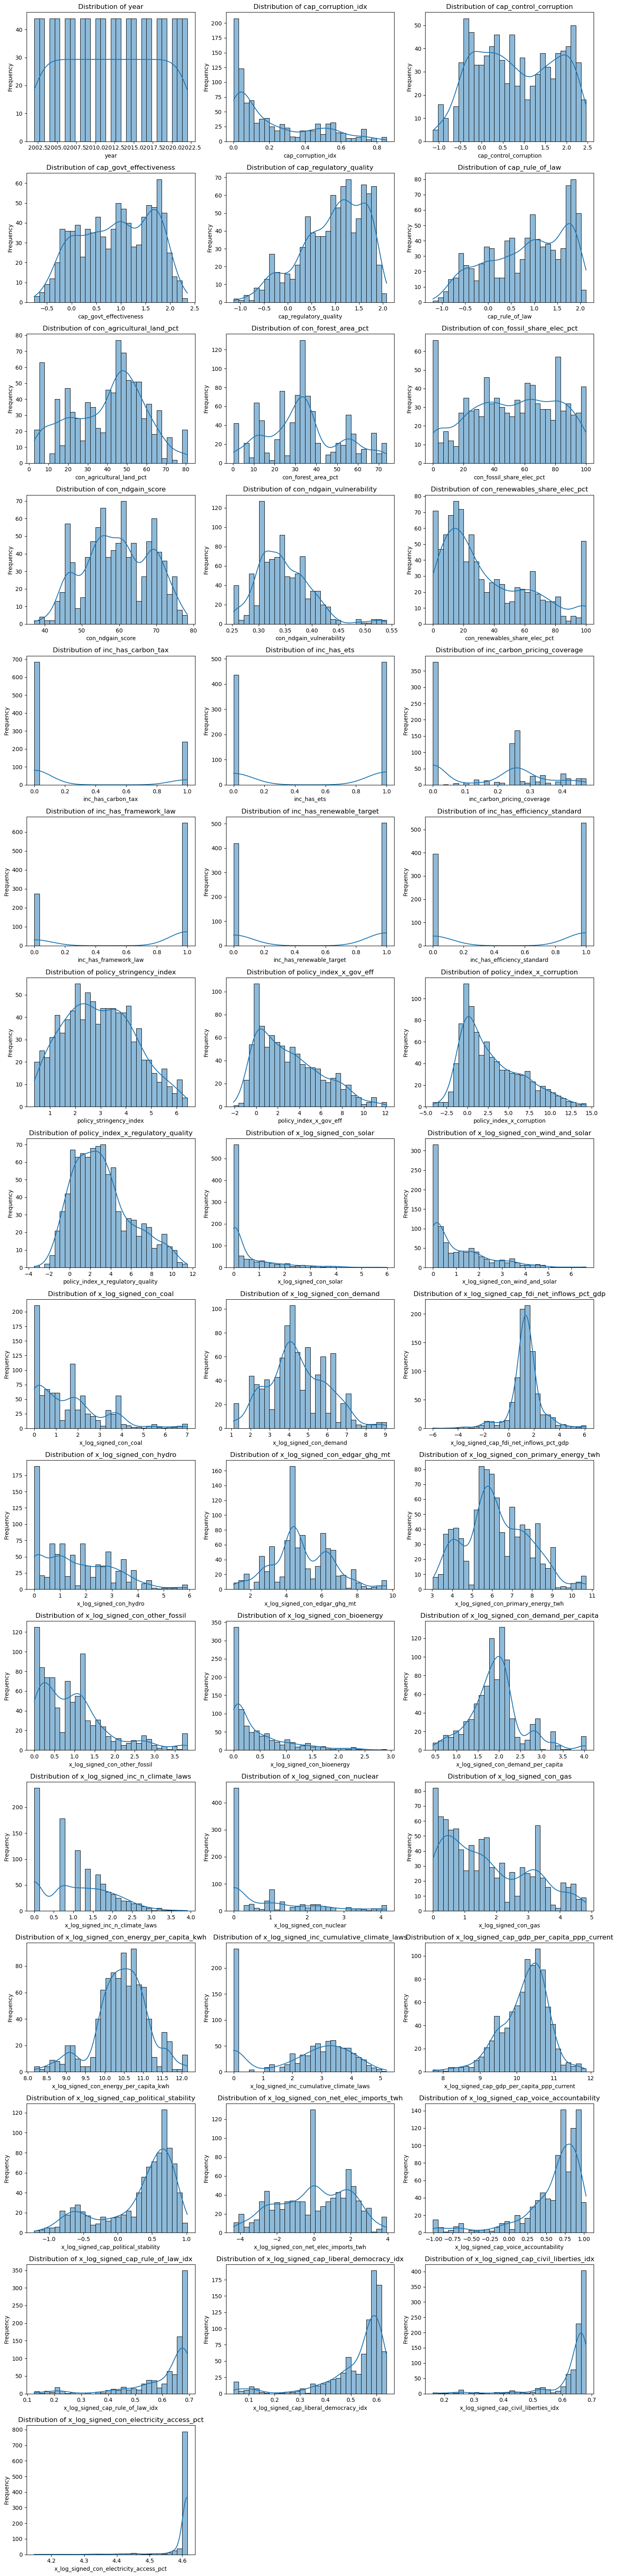

In [72]:
eda_utils.plot_numeric_fields_distributions(df_log_transformed)

In [73]:
df_log_transformed.columns

Index(['iso_alpha_3', 'year', 'cap_corruption_idx', 'cap_control_corruption',
       'cap_govt_effectiveness', 'cap_regulatory_quality', 'cap_rule_of_law',
       'con_agricultural_land_pct', 'con_forest_area_pct',
       'con_fossil_share_elec_pct', 'con_ndgain_score',
       'con_ndgain_vulnerability', 'con_renewables_share_elec_pct',
       'inc_has_carbon_tax', 'inc_has_ets', 'inc_carbon_pricing_coverage',
       'inc_has_framework_law', 'inc_has_renewable_target',
       'inc_has_efficiency_standard', 'policy_stringency_index',
       'policy_index_x_gov_eff', 'policy_index_x_corruption',
       'policy_index_x_regulatory_quality', 'x_log_signed_con_solar',
       'x_log_signed_con_wind_and_solar', 'x_log_signed_con_coal',
       'x_log_signed_con_demand', 'x_log_signed_cap_fdi_net_inflows_pct_gdp',
       'x_log_signed_con_hydro', 'x_log_signed_con_edgar_ghg_mt',
       'x_log_signed_con_primary_energy_twh', 'x_log_signed_con_other_fossil',
       'x_log_signed_con_bioenergy', 'x

### Generate lags

In [74]:
policy_lag_base_features = [
    "inc_has_efficiency_standard",
    "inc_has_renewable_target",
    "inc_has_carbon_tax",
    "inc_has_ets",
    "inc_carbon_pricing_coverage", # NOTE: This didn't get log transformation since it became unskewed after inner merge with policy data
    "x_log_signed_inc_n_climate_laws",
]

policy_lag_specs = {
    feature: [1, 2]
    for feature in policy_lag_base_features
}

for feature in [
    "inc_has_efficiency_standard",
    "inc_has_renewable_target",
    "inc_has_carbon_tax",
    "inc_has_ets",
]:
    policy_lag_specs[feature] = [1, 2, 3]

missing_policy_lag_features = [
    feature for feature in policy_lag_base_features
    if feature not in df_log_transformed.columns
]

if missing_policy_lag_features:
    raise KeyError(f"Missing policy lag features: {missing_policy_lag_features}")

df_log_transformed = (
    df_log_transformed
    .sort_values(["iso_alpha_3", "year"])
    .reset_index(drop=True)
    .copy()
)

policy_lag_feature_cols = []

for feature, lag_years in policy_lag_specs.items():
    for lag_year in lag_years:
        lag_col = f"{feature}_lag_{lag_year}y"
        df_log_transformed[lag_col] = (
            df_log_transformed
            .groupby("iso_alpha_3", sort=False)[feature]
            .shift(lag_year)
        )
        policy_lag_feature_cols.append(lag_col)

policy_lag_feature_cols

['inc_has_efficiency_standard_lag_1y',
 'inc_has_efficiency_standard_lag_2y',
 'inc_has_efficiency_standard_lag_3y',
 'inc_has_renewable_target_lag_1y',
 'inc_has_renewable_target_lag_2y',
 'inc_has_renewable_target_lag_3y',
 'inc_has_carbon_tax_lag_1y',
 'inc_has_carbon_tax_lag_2y',
 'inc_has_carbon_tax_lag_3y',
 'inc_has_ets_lag_1y',
 'inc_has_ets_lag_2y',
 'inc_has_ets_lag_3y',
 'inc_carbon_pricing_coverage_lag_1y',
 'inc_carbon_pricing_coverage_lag_2y',
 'x_log_signed_inc_n_climate_laws_lag_1y',
 'x_log_signed_inc_n_climate_laws_lag_2y']

In [75]:
df_log_transformed[
    ["iso_alpha_3", "year"] + policy_lag_base_features + policy_lag_feature_cols
].head(10)

,iso_alpha_3,year,inc_has_efficiency_standard,inc_has_renewable_target,inc_has_carbon_tax,inc_has_ets,inc_carbon_pricing_coverage,x_log_signed_inc_n_climate_laws,inc_has_efficiency_standard_lag_1y,inc_has_efficiency_standard_lag_2y,...,inc_has_carbon_tax_lag_1y,inc_has_carbon_tax_lag_2y,inc_has_carbon_tax_lag_3y,inc_has_ets_lag_1y,inc_has_ets_lag_2y,inc_has_ets_lag_3y,inc_carbon_pricing_coverage_lag_1y,inc_carbon_pricing_coverage_lag_2y,x_log_signed_inc_n_climate_laws_lag_1y,x_log_signed_inc_n_climate_laws_lag_2y
0,ARG,2002,1.0,1.0,0.0,0.0,0.0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ARG,2003,1.0,1.0,0.0,0.0,0.0,0.000000,1.0,NaN,...,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.000000,NaN
2,ARG,2004,0.0,1.0,0.0,0.0,0.0,0.693147,1.0,1.0,...,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.000000,0.000000
3,ARG,2005,1.0,1.0,0.0,0.0,0.0,1.098612,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.693147,0.000000
4,ARG,2006,0.0,1.0,0.0,0.0,0.0,1.098612,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.098612,0.693147
5,ARG,2007,1.0,1.0,0.0,0.0,0.0,1.609438,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.098612,1.098612
6,ARG,2008,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.609438,1.098612
7,ARG,2009,1.0,0.0,0.0,0.0,0.0,1.098612,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.609438
8,ARG,2010,1.0,1.0,0.0,0.0,0.0,1.098612,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.098612,0.000000
9,ARG,2011,1.0,1.0,0.0,0.0,0.0,0.000000,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.098612,1.098612


## ML

In [76]:
# Sort the dataframe by country and year to ensure proper temporal ordering for modeling
training_df = df_log_transformed.sort_values(by=["iso_alpha_3", "year"]).reset_index(drop=True)
training_df.head()

,iso_alpha_3,year,cap_corruption_idx,cap_control_corruption,cap_govt_effectiveness,cap_regulatory_quality,cap_rule_of_law,con_agricultural_land_pct,con_forest_area_pct,con_fossil_share_elec_pct,...,inc_has_carbon_tax_lag_1y,inc_has_carbon_tax_lag_2y,inc_has_carbon_tax_lag_3y,inc_has_ets_lag_1y,inc_has_ets_lag_2y,inc_has_ets_lag_3y,inc_carbon_pricing_coverage_lag_1y,inc_carbon_pricing_coverage_lag_2y,x_log_signed_inc_n_climate_laws_lag_1y,x_log_signed_inc_n_climate_laws_lag_2y
0,ARG,2002,0.518,-0.417056,-0.228479,-0.880717,-0.761098,47.031268,11.965257,50.112,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ARG,2003,0.555,-0.479977,-0.034220,-0.691476,-0.777116,47.174981,11.849643,54.024,...,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.000000,NaN
2,ARG,2004,0.555,-0.414410,0.015197,-0.698035,-0.767380,47.318695,11.734029,60.832,...,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.000000,0.000000
3,ARG,2005,0.555,-0.377738,-0.097979,-0.525074,-0.557991,47.473737,11.618415,60.208,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.693147,0.000000
4,ARG,2006,0.555,-0.331239,-0.033916,-0.614567,-0.577016,47.553395,11.502801,58.688,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.098612,0.693147


In [77]:
training_df.year.max()

np.int64(2022)

In [78]:
target_var = "x_log_signed_con_edgar_ghg_mt"

### Train the model with reduced set of features informed by ablation experiment

In [79]:
top_features_ablation = [
        'x_log_signed_con_solar', 
        'inc_has_efficiency_standard',
        'inc_has_renewable_target', 
        'x_log_signed_con_net_elec_imports_twh', #NOTE: This got log transformation since it became skewed after inner merge with policy data
        'x_log_signed_cap_civil_liberties_idx', 
        'inc_has_carbon_tax',
        'inc_has_ets',
        'inc_carbon_pricing_coverage', # NOTE: This didn't get log transformation since it became unskewed after inner merge with policy data
        'con_forest_area_pct',
        'con_agricultural_land_pct',
        'x_log_signed_con_nuclear',
        'x_log_signed_con_electricity_access_pct', 
        'inc_has_framework_law',
        'x_log_signed_inc_n_climate_laws',
        'x_log_signed_inc_cumulative_climate_laws',
        'con_fossil_share_elec_pct', 
        'con_renewables_share_elec_pct',
        'x_log_signed_con_primary_energy_twh',
        'x_log_signed_con_hydro',
        'x_log_signed_con_demand',
        'x_log_signed_con_coal',
        'x_log_signed_con_gas',
        'x_log_signed_con_demand_per_capita',
        'cap_regulatory_quality',
        'cap_rule_of_law',
        'cap_govt_effectiveness',
        'con_ndgain_score',
        "policy_stringency_index", #NOTE: This is the main variable of interest that we are adding in this robustness check
        'policy_index_x_gov_eff',
        'policy_index_x_corruption',
        'policy_index_x_regulatory_quality'
        ]

# Include policy lag features if they exist
if "policy_lag_feature_cols" in globals():
    top_features_ablation = top_features_ablation + policy_lag_feature_cols




In [80]:
columns_to_filter = ["iso_alpha_3", "year", target_var] + top_features_ablation
columns_to_filter

['iso_alpha_3',
 'year',
 'x_log_signed_con_edgar_ghg_mt',
 'x_log_signed_con_solar',
 'inc_has_efficiency_standard',
 'inc_has_renewable_target',
 'x_log_signed_con_net_elec_imports_twh',
 'x_log_signed_cap_civil_liberties_idx',
 'inc_has_carbon_tax',
 'inc_has_ets',
 'inc_carbon_pricing_coverage',
 'con_forest_area_pct',
 'con_agricultural_land_pct',
 'x_log_signed_con_nuclear',
 'x_log_signed_con_electricity_access_pct',
 'inc_has_framework_law',
 'x_log_signed_inc_n_climate_laws',
 'x_log_signed_inc_cumulative_climate_laws',
 'con_fossil_share_elec_pct',
 'con_renewables_share_elec_pct',
 'x_log_signed_con_primary_energy_twh',
 'x_log_signed_con_hydro',
 'x_log_signed_con_demand',
 'x_log_signed_con_coal',
 'x_log_signed_con_gas',
 'x_log_signed_con_demand_per_capita',
 'cap_regulatory_quality',
 'cap_rule_of_law',
 'cap_govt_effectiveness',
 'con_ndgain_score',
 'policy_stringency_index',
 'policy_index_x_gov_eff',
 'policy_index_x_corruption',
 'policy_index_x_regulatory_quality'

In [81]:
training_df_after_ablation = training_df[columns_to_filter]
training_df_after_ablation.head()

,iso_alpha_3,year,x_log_signed_con_edgar_ghg_mt,x_log_signed_con_solar,inc_has_efficiency_standard,inc_has_renewable_target,x_log_signed_con_net_elec_imports_twh,x_log_signed_cap_civil_liberties_idx,inc_has_carbon_tax,inc_has_ets,...,inc_has_carbon_tax_lag_1y,inc_has_carbon_tax_lag_2y,inc_has_carbon_tax_lag_3y,inc_has_ets_lag_1y,inc_has_ets_lag_2y,inc_has_ets_lag_3y,inc_carbon_pricing_coverage_lag_1y,inc_carbon_pricing_coverage_lag_2y,x_log_signed_inc_n_climate_laws_lag_1y,x_log_signed_inc_n_climate_laws_lag_2y
0,ARG,2002,5.701782,0.0,1.0,1.0,1.934416,0.654406,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ARG,2003,5.776376,0.0,1.0,1.0,1.796747,0.650761,0.0,0.0,...,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.000000,NaN
2,ARG,2004,5.837048,0.0,0.0,1.0,1.497388,0.650761,0.0,0.0,...,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.000000,0.000000
3,ARG,2005,5.845939,0.0,1.0,1.0,1.585145,0.650761,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.693147,0.000000
4,ARG,2006,5.884939,0.0,0.0,1.0,1.211941,0.649195,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.098612,0.693147


In [82]:
training_df_after_ablation.columns

Index(['iso_alpha_3', 'year', 'x_log_signed_con_edgar_ghg_mt',
       'x_log_signed_con_solar', 'inc_has_efficiency_standard',
       'inc_has_renewable_target', 'x_log_signed_con_net_elec_imports_twh',
       'x_log_signed_cap_civil_liberties_idx', 'inc_has_carbon_tax',
       'inc_has_ets', 'inc_carbon_pricing_coverage', 'con_forest_area_pct',
       'con_agricultural_land_pct', 'x_log_signed_con_nuclear',
       'x_log_signed_con_electricity_access_pct', 'inc_has_framework_law',
       'x_log_signed_inc_n_climate_laws',
       'x_log_signed_inc_cumulative_climate_laws', 'con_fossil_share_elec_pct',
       'con_renewables_share_elec_pct', 'x_log_signed_con_primary_energy_twh',
       'x_log_signed_con_hydro', 'x_log_signed_con_demand',
       'x_log_signed_con_coal', 'x_log_signed_con_gas',
       'x_log_signed_con_demand_per_capita', 'cap_regulatory_quality',
       'cap_rule_of_law', 'cap_govt_effectiveness', 'con_ndgain_score',
       'policy_stringency_index', 'policy_index_x_gov

In [83]:
training_df_after_ablation = training_df_after_ablation.sort_values(["iso_alpha_3", "year"]).copy()

# # ================================
# # 1. 1-year lag of emissions (no leakage)
# # ================================

# training_df_after_ablation["em_lag_1y"] = (
#     training_df_after_ablation
#     .groupby("iso_alpha_3")["x_log_signed_con_edgar_ghg_mt"]
#     .shift(1)
# )

# ================================
# Helper function to compute slope
# ================================

def compute_slope(series):
    x = np.arange(len(series))
    y = series.values
    return np.polyfit(x, y, 1)[0]


# ================================
# 2. 3-year rolling trend
# ================================

training_df_after_ablation["em_trend_3y"] = (
    training_df_after_ablation
    .groupby("iso_alpha_3")["x_log_signed_con_edgar_ghg_mt"]
    .rolling(window=3, min_periods=2)
    .apply(compute_slope, raw=False)
    .reset_index(level=0, drop=True)
)

# shift to avoid leakage
training_df_after_ablation["em_trend_3y"] = (
    training_df_after_ablation
    .groupby("iso_alpha_3")["em_trend_3y"]
    .shift(1)
)


# ================================
# 3. 5-year rolling trend
# ================================

training_df_after_ablation["em_trend_5y"] = (
    training_df_after_ablation
    .groupby("iso_alpha_3")["x_log_signed_con_edgar_ghg_mt"]
    .rolling(window=5, min_periods=3)
    .apply(compute_slope, raw=False)
    .reset_index(level=0, drop=True)
)

# shift to avoid leakage
training_df_after_ablation["em_trend_5y"] = (
    training_df_after_ablation
    .groupby("iso_alpha_3")["em_trend_5y"]
    .shift(1)
)


# ================================
# 4. Trend acceleration
# ================================

training_df_after_ablation["em_acceleration"] = (
    training_df_after_ablation["em_trend_3y"] -
    training_df_after_ablation["em_trend_5y"]
)


# ================================
# 5. Rolling volatility (5y std)
# ================================

training_df_after_ablation["em_volatility_5y"] = (
    training_df_after_ablation
    .groupby("iso_alpha_3")["x_log_signed_con_edgar_ghg_mt"]
    .rolling(window=5, min_periods=3)
    .std()
    .reset_index(level=0, drop=True)
)

# shift to avoid leakage
training_df_after_ablation["em_volatility_5y"] = (
    training_df_after_ablation
    .groupby("iso_alpha_3")["em_volatility_5y"]
    .shift(1)
)

In [84]:
training_df_after_ablation = training_df_after_ablation.dropna()
training_df_after_ablation

,iso_alpha_3,year,x_log_signed_con_edgar_ghg_mt,x_log_signed_con_solar,inc_has_efficiency_standard,inc_has_renewable_target,x_log_signed_con_net_elec_imports_twh,x_log_signed_cap_civil_liberties_idx,inc_has_carbon_tax,inc_has_ets,...,inc_has_ets_lag_2y,inc_has_ets_lag_3y,inc_carbon_pricing_coverage_lag_1y,inc_carbon_pricing_coverage_lag_2y,x_log_signed_inc_n_climate_laws_lag_1y,x_log_signed_inc_n_climate_laws_lag_2y,em_trend_3y,em_trend_5y,em_acceleration,em_volatility_5y
3,ARG,2005,5.845939,0.000000,1.0,1.0,1.585145,0.650761,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.693147,0.000000,0.067633,0.067633,0.000000,0.067752
4,ARG,2006,5.884939,0.000000,0.0,1.0,1.211941,0.649195,0.0,0.0,...,0.0,0.0,0.000000,0.000000,1.098612,0.693147,0.034781,0.049314,-0.014533,0.066609
5,ARG,2007,5.903619,0.000000,1.0,1.0,2.151762,0.647103,0.0,0.0,...,0.0,0.0,0.000000,0.000000,1.098612,1.098612,0.023946,0.043588,-0.019642,0.071550
6,ARG,2008,5.905544,0.000000,0.0,0.0,1.868721,0.644482,0.0,0.0,...,0.0,0.0,0.000000,0.000000,1.609438,1.098612,0.028840,0.030238,-0.001398,0.049243
7,ARG,2009,5.841362,0.000000,1.0,0.0,1.968510,0.643957,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.000000,1.609438,0.010302,0.019467,-0.009165,0.032151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
919,ZAF,2018,6.408181,1.759581,1.0,0.0,-1.740466,0.617345,0.0,0.0,...,0.0,0.0,0.000000,0.000000,1.609438,0.693147,0.010618,-0.003857,0.014475,0.017406
920,ZAF,2019,6.416955,1.776646,1.0,1.0,-1.819699,0.608134,1.0,0.0,...,0.0,0.0,0.000000,0.000000,2.197225,1.609438,0.012851,-0.001037,0.013888,0.017921
921,ZAF,2020,6.314389,1.944481,1.0,1.0,-1.572774,0.603769,1.0,0.0,...,0.0,0.0,0.342282,0.000000,1.945910,2.197225,0.006878,0.009569,-0.002691,0.015705
922,ZAF,2021,6.308965,1.990610,1.0,1.0,-1.519513,0.608678,1.0,0.0,...,0.0,0.0,0.342282,0.342282,2.708050,1.945910,-0.046896,-0.012242,-0.034654,0.041479


In [85]:
features_list = training_df_after_ablation.columns[
    ~training_df_after_ablation.columns.isin(["iso_alpha_3", "year", target_var])
].tolist()

features_list

['x_log_signed_con_solar',
 'inc_has_efficiency_standard',
 'inc_has_renewable_target',
 'x_log_signed_con_net_elec_imports_twh',
 'x_log_signed_cap_civil_liberties_idx',
 'inc_has_carbon_tax',
 'inc_has_ets',
 'inc_carbon_pricing_coverage',
 'con_forest_area_pct',
 'con_agricultural_land_pct',
 'x_log_signed_con_nuclear',
 'x_log_signed_con_electricity_access_pct',
 'inc_has_framework_law',
 'x_log_signed_inc_n_climate_laws',
 'x_log_signed_inc_cumulative_climate_laws',
 'con_fossil_share_elec_pct',
 'con_renewables_share_elec_pct',
 'x_log_signed_con_primary_energy_twh',
 'x_log_signed_con_hydro',
 'x_log_signed_con_demand',
 'x_log_signed_con_coal',
 'x_log_signed_con_gas',
 'x_log_signed_con_demand_per_capita',
 'cap_regulatory_quality',
 'cap_rule_of_law',
 'cap_govt_effectiveness',
 'con_ndgain_score',
 'policy_stringency_index',
 'policy_index_x_gov_eff',
 'policy_index_x_corruption',
 'policy_index_x_regulatory_quality',
 'inc_has_efficiency_standard_lag_1y',
 'inc_has_efficien

In [86]:
print("Running regression without group feature...")

enet_params = dict(
    l1_ratio=[0.01],
    n_alphas=300,          # wider alpha search
    eps=1e-4,              # allow smaller alphas
    cv=7,
    max_iter=30000,
    n_jobs=1,
    random_state=42,
)


ra_4 = RegressionAnalysis(
    df=training_df_after_ablation,
    target_col=target_var,
    group_col="iso_alpha_3",
    year_col="year",
    holdout_years=5,
    scaler_type="standard",
    feature_cols=features_list,
    include_year=False,
    enet_params=enet_params
)

ra_4.cross_validate()
ra_4.fit()
ra_4.evaluate()

Running regression without group feature...

Cross-validation results:
------------------------------------------------------------------------------------------
Model               Time MAE    Group MAE


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_desc

ElasticNet            0.0988          nan
RandomForest          0.0782       0.3378
XGBoost               0.0779       0.3449
Median                1.2924       1.3195


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(



Holdout evaluation:
------------------------------------------------------------------------------------------------------------------------
Model          Train MAE (log) Test MAE (log)  Train RMSE (log)   Test RMSE (log)   Train MAE (level)    Test MAE (level)
------------------------------------------------------------------------------------------------------------------------
ElasticNet              0.0712         0.1100            0.0928            0.1589               31.15               60.79
RandomForest            0.0128         0.0869            0.0218            0.1336               10.35              167.12
XGBoost                 0.0026         0.0904            0.0033            0.1241                1.29              151.14
Median                  1.2880         1.3273            1.6894            1.7332              556.82              644.78


{'ElasticNet': {'train_mae_log': 0.07122473263567998,
  'test_mae_log': 0.1100266790520095,
  'train_rmse_log': 0.09282055356810356,
  'test_rmse_log': 0.15891284632625674,
  'train_mae_level': np.float64(31.147925483116683),
  'test_mae_level': np.float64(60.79115008423707)},
 'RandomForest': {'train_mae_log': 0.01279988615201223,
  'test_mae_log': 0.0868542500842166,
  'train_rmse_log': 0.021823134520114085,
  'test_rmse_log': 0.13363892385763723,
  'train_mae_level': np.float64(10.345246238652253),
  'test_mae_level': np.float64(167.11648703714124)},
 'XGBoost': {'train_mae_log': 0.0025585857793584002,
  'test_mae_log': 0.09041606326591482,
  'train_rmse_log': 0.0033359595635077135,
  'test_rmse_log': 0.12409404046553056,
  'train_mae_level': np.float64(1.2899842827702879),
  'test_mae_level': np.float64(151.1412743843801)},
 'Median': {'train_mae_log': 1.2879520217964504,
  'test_mae_log': 1.3273400988499,
  'train_rmse_log': 1.6893727810922712,
  'test_rmse_log': 1.733208899232440

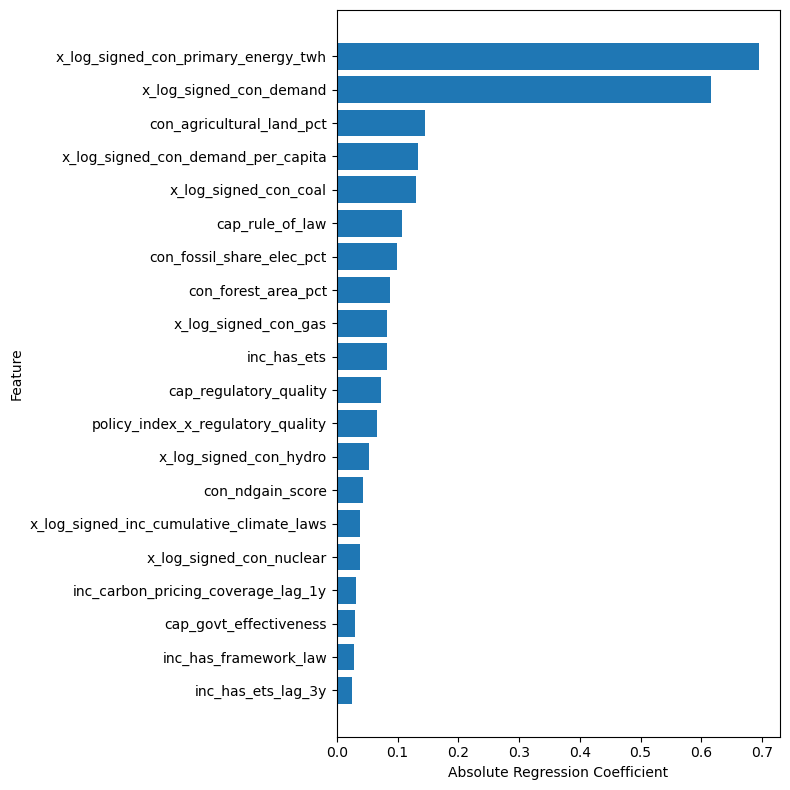

In [87]:
ra_4.plot_top_enet_regressors()

In [88]:
# one model
ra_4.get_model_hyperparameters("ElasticNet")

{'ElasticNet': {'is_fitted': True,
  'hyperparameters': {'alphas': 'warn',
   'copy_X': True,
   'cv': TimeSeriesSplit(gap=0, max_train_size=None, n_splits=7, test_size=None),
   'eps': 0.0001,
   'fit_intercept': True,
   'l1_ratio': [0.01],
   'max_iter': 30000,
   'n_alphas': 300,
   'n_jobs': 1,
   'positive': False,
   'precompute': 'auto',
   'random_state': 42,
   'selection': 'cyclic',
   'tol': 0.0001,
   'verbose': 0},
  'selected_alpha': 0.016210330580670517,
  'selected_l1_ratio': 0.01,
  'n_iter': 190}}

In [89]:
# df_l1 = ra_4.enet_l1_ratio_experiment(
#     l1_ratios=[0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95],
#     plot=True,
# )
# df_l1

### Save model

In [ ]:
# obtain timestamp
timestamp = int(time.time())

In [ ]:
# --------------------------------------------------
# Save the training data with predictions
# --------------------------------------------------
training_df_after_ablation.to_csv(
    os.path.join(TRAINING_DIR_PATH, f"training_df_{timestamp}.csv"),
    index=False
)

# --------------------------------------------------
# Select trained pipelines to save
# --------------------------------------------------
trained_pipelines = {
    "enet": ra_4.pipe_enet,   # <- THIS is the key line
}

rewrite_existing_models = False

# --------------------------------------------------
# Save pipelines
# --------------------------------------------------
for name, pipeline in trained_pipelines.items():
    model_file_name = f"{name}_pipeline_{timestamp}.pkl"
    model_path = os.path.join(MODELS_DIR_PATH, model_file_name)

    if os.path.exists(model_path) and not rewrite_existing_models:
        print(f"Model {model_file_name} already exists. Skipping save.")
        continue

    if os.path.exists(model_path):
        print(f"Overwriting existing model at {model_path}")
    else:
        print(f"Saving model to {model_path}")

    joblib.dump(pipeline, model_path)